In [1]:
import kagglehub
path = kagglehub.dataset_download("durgeshrao9993/twitter-analysis-dataset-2022")

print("Path to dataset files:", path)

100%|██████████| 1.23M/1.23M [00:00<00:00, 99.6MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/durgeshrao9993/twitter-analysis-dataset-2022/versions/2


In [2]:
!pip install pandas numpy scikit-learn nltk matplotlib

In [3]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

In [4]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [5]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

In [6]:
from google.colab import files
uploaded = files.upload()

Saving twitter.csv.zip to twitter.csv.zip


In [8]:
import zipfile

with zipfile.ZipFile('twitter.csv.zip', 'r') as zip_ref:
    zip_ref.extractall()

df = pd.read_csv("twitter.csv")
df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [9]:
df = df.rename(columns={
    "sentence": "text",
    "label": "sentiment"
})

In [10]:
df["sentiment"] = df["sentiment"].map({
    1: "positive",
    0: "negative"
})

In [12]:
df["cleaned_text"] = df["tweet"].apply(clean_text)
df.head()

,id,sentiment,tweet,cleaned_text
0,1,negative,@user when a father is dysfunctional and is s...,user father dysfunctional selfish drags kids d...
1,2,negative,@user @user thanks for #lyft credit i can't us...,user user thanks lyft credit cant use cause do...
2,3,negative,bihday your majesty,bihday majesty
3,4,negative,#model i love u take with u all the time in ...,model love u take u time ur
4,5,negative,factsguide: society now #motivation,factsguide society motivation


In [13]:
X = df["cleaned_text"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000)),
    ("clf", LinearSVC())
])

model.fit(X_train, y_train)
print("Model trained successfully")

Model trained successfully


In [15]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9593305177537932

Classification Report:

              precision    recall  f1-score   support

    negative       0.97      0.99      0.98      5945
    positive       0.80      0.56      0.66       448

    accuracy                           0.96      6393
   macro avg       0.89      0.77      0.82      6393
weighted avg       0.96      0.96      0.96      6393



In [16]:
sample = "I really hate this product"
sample_clean = clean_text(sample)

print("Prediction:", model.predict([sample_clean])[0])

Prediction: negative


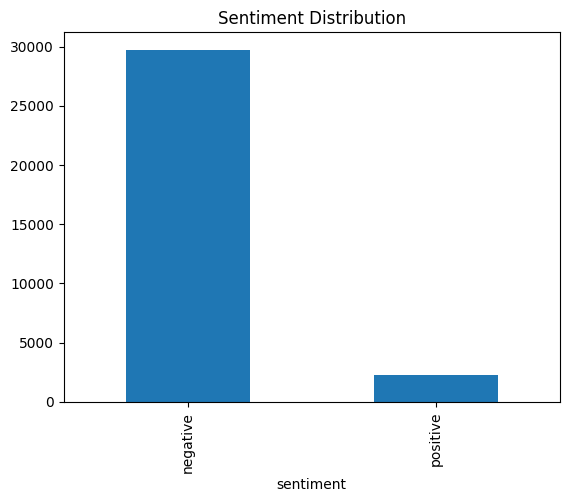

In [17]:
df["sentiment"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution")
plt.show()

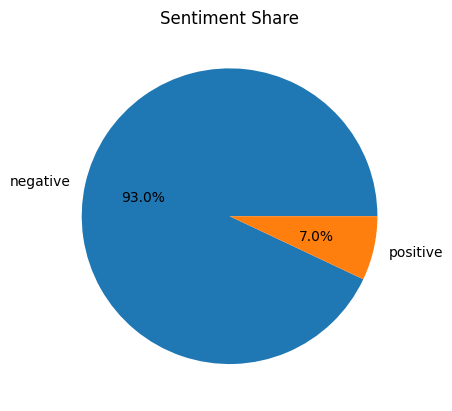

In [18]:
df["sentiment"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Sentiment Share")
plt.ylabel("")
plt.show()